<a href="https://colab.research.google.com/github/SamuelOpong07/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

print("Running on:", DEVICE)

Running on: cpu


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

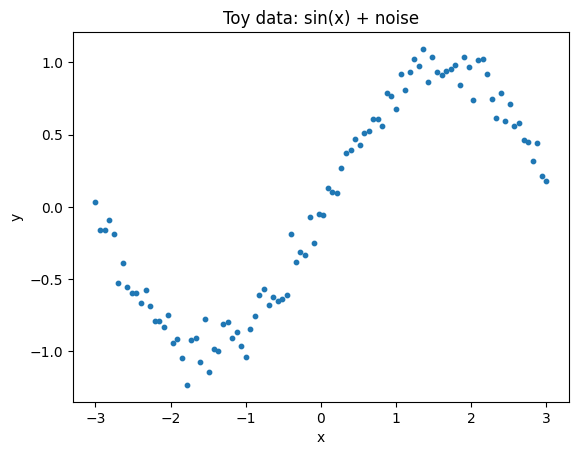

Final w: 0.3318, b: 0.0060,  final loss: 0.1791


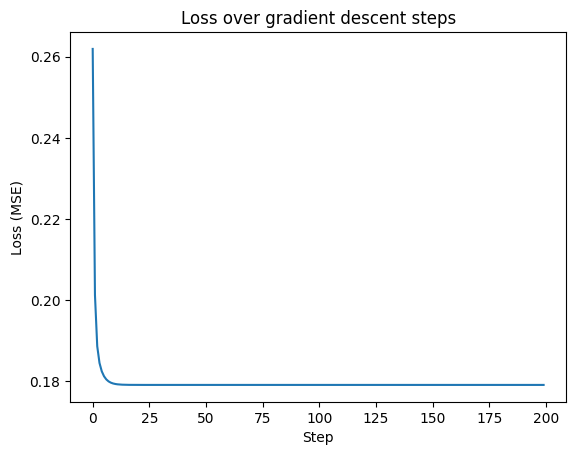

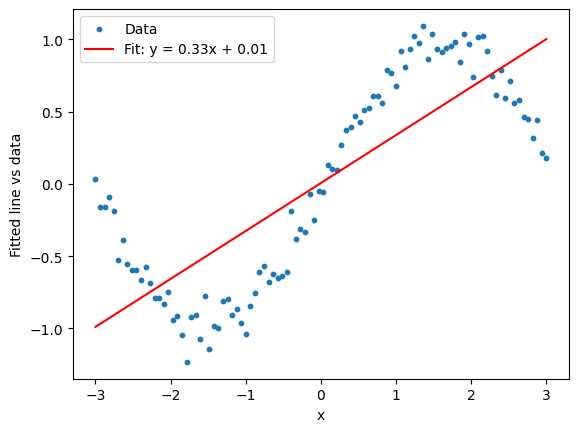

In [24]:
# Part 1.1 — A single neuron is just a line

# TODO: Generate the toy data
np.random.seed(0)
x = np.linspace(-3, 3, 100)
noise = np.random.normal(loc=0, scale=0.1, size=x.shape)
y = np.sin(x) + noise

#Plotting
plt.scatter(x, y, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy data: sin(x) + noise")
plt.show()


# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1


lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw    = np.mean(2 * (y_hat - y) * x)
    db    = np.mean(2 * (y_hat - y))

    w    -= lr * dw
    b    -= lr * db

print(f"Final w: {w:.4f}, b: {b:.4f},  final loss: {losses[-1]:.4f}")


# Plotting the loss curve over the 200 steps:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss over gradient descent steps")
plt.show()


#Plotting the data with the fitted line on top:
plt.scatter(x, y, s=10, label="Data")
plt.plot(x, w * x + b, color="red", label=f"Fit: y = {w:.2f}x + {b:.2f}")
plt.xlabel("x")
plt.ylabel("Fitted line vs data")
plt.legend()
plt.show()

Student Reasoning — The single neuron 
1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code? 

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

Final loss:  0.02057


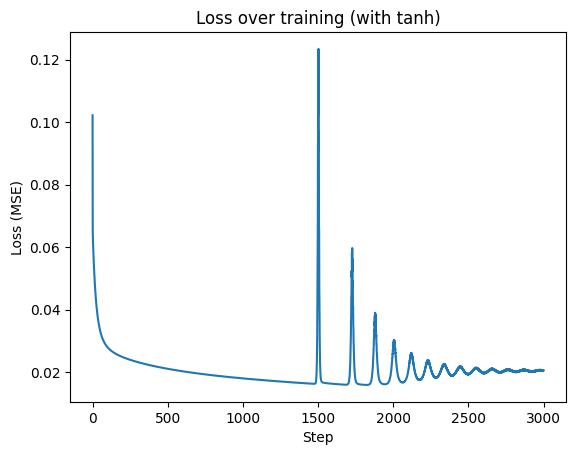

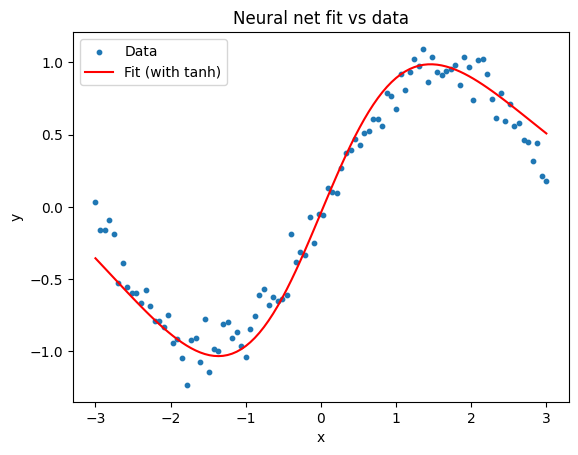

In [25]:
# Part 1.2 — Hidden layers and activations: why depth helps
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)




# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1     = x @ W1 + b1
h      = np.tanh(z1)
y_hat  = h @ W2 + b2
loss   = np.mean((y_hat - y) ** 2)



# TODO: Backward pass (the chain rule, layer by layer):
d_yhat   = 2 * (y_hat - y) / len(y)
dw2      = h.T @ d_yhat 
db2      = d_yhat.sum(axis=0)
dh       = d_yhat @ W2.T
dz1      = dh * (1 - np.tanh(z1) ** 2)
dw1      = x.T @ dz1
db1      = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps
lr      = 0.1
n_steps = 3000
losses  = []

for step in range(n_steps):
    #Forward pass
    z1     = x @ W1 + b1
    h      = np.tanh(z1)
    y_hat  = h @ W2 + b2
    loss   = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #Backward pass
    d_yhat   = 2 * (y_hat - y) / len(y)
    dw2      = h.T @ d_yhat 
    db2      = d_yhat.sum(axis=0)
    dh       = d_yhat @ W2.T
    dz1      = dh * (1 - np.tanh(z1) ** 2)
    dw1      = x.T @ dz1
    db1      = dz1.sum(axis=0)

    #Update
    W1 -= lr * dw1
    b1 -= lr * db1
    W2 -= lr * dw2
    b2 -= lr * db2

print(f"Final loss:  {losses[-1]:.5f}")



# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss over training (with tanh)")
plt.show()

#Fit vs data
plt.scatter(x, y, s=10, label="Data")

#sort x for a clean line
z1_final  = x @ W1 + b1
h_final   = np.tanh(z1_final)
y_pred    = h_final @ W2 + b2

plt.plot(x, y_pred, color="red", label="Fit (with tanh)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural net fit vs data")
plt.legend()
plt.show()


c:\Users\Samuel\Documents\AI\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Samuel\AppData\Local\Temp\ipykernel_30440\1546582740.py:17: RuntimeWarning: overflow encountered in square
  loss   = np.mean((y_hat - y) ** 2)
C:\Users\Samuel\AppData\Local\Temp\ipykernel_30440\1546582740.py:24: RuntimeWarning: overflow encountered in matmul
  dh       = d_yhat @ W2.T
C:\Users\Samuel\AppData\Local\Temp\ipykernel_30440\1546582740.py:25: RuntimeWarning: invalid value encountered in multiply
  dz1      = dh * (1 - np.tanh(z1) ** 2)
c:\Users\Samuel\Documents\AI\.venv\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


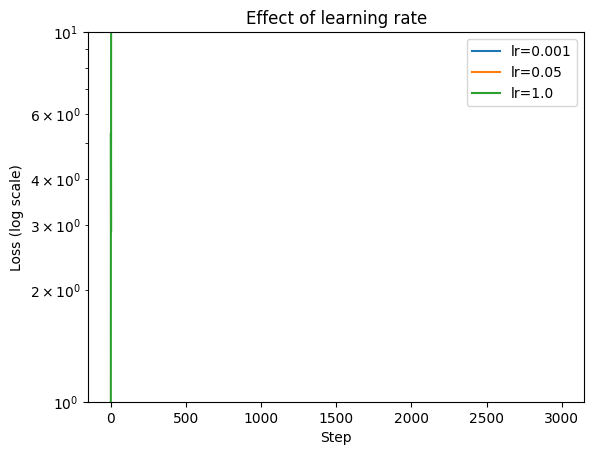

In [26]:
# Part 1.3 — The learning rate: too cold, too hot, just right

# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
def train_toy(lr, steps=3000):
    np.random.seed(0)
    W1  = np.random.randn(1, 8) * 0.5
    b1  = np.zeros(8)
    W2  = np.random.randn(8, 1) * 0.5
    b2  = np.zeros(1)

    losses = []
    for step in range(steps):
        #forward pass
        z1     = x @ W1 + b1
        h      = np.tanh(z1)
        y_hat  = h @ W2 + b2
        loss   = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        #backward pass
        d_yhat   = 2 * (y_hat - y) / len(y)
        dw2      = h.T @ d_yhat 
        db2      = d_yhat.sum(axis=0)
        dh       = d_yhat @ W2.T
        dz1      = dh * (1 - np.tanh(z1) ** 2)
        dw1      = x.T @ dz1
        db1      = dz1.sum(axis=0)

        #Update
        W1 -= lr * dw1
        b1 -= lr * db1
        W2 -= lr * dw2
        b2 -= lr * db2

    return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
losses_low = train_toy(lr=0.001)
losses_mid = train_toy(lr=0.05)
losses_high = train_toy(lr=1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.plot(losses_low, label="lr=0.001")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_high, label="lr=1.0")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.legend()
plt.title("Effect of learning rate")
plt.show()
  

Section 2 — A Real Feedforward Network in PyTorch

Predicting obesity level (NObeyesdad) — the Lab 2 dataset

In [27]:
# Part 2.1 — Preprocess and split (recycled from Lab 2)

import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
obesity = pd.read_csv(OBESITY_URL)

binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
obesity[binary_cols] = obesity[binary_cols].replace({'yes': 1, 'no': 0})

ordinal_cols = ['CAEC', 'CALC']
ordinal_order = [['no', 'Sometimes', 'Frequently', 'Always'],
                 ['no', 'Sometimes', 'Frequently', 'Always']]

# TODO: Encode categoricals exactly as you did in Lab 2

oe = OrdinalEncoder(categories=ordinal_order)
obesity[ordinal_cols] = oe.fit_transform(obesity[ordinal_cols])

obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

le = LabelEncoder()
obesity['NObeyesdad'] = le.fit_transform(obesity['NObeyesdad'])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size= 0.2, random_state= RANDOM_STATE, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state= RANDOM_STATE, stratify=y_temp)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val  = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader


# Convert to tensors
X_train_t  = torch.tensor(X_train, dtype=torch.float32)
X_val_t    = torch.tensor(X_val, dtype=torch.float32)
X_test_t   = torch.tensor(X_test, dtype=torch.float32)

y_train_t  = torch.tensor(y_train.values, dtype=torch.long)
y_val_t    = torch.tensor(y_val.values, dtype=torch.long)
y_test_t   = torch.tensor(y_test.values, dtype=torch.long)

#Wrap in TensorDatasets
train_dataset  = TensorDataset(X_train_t, y_train_t)
val_dataset    = TensorDataset(X_val_t, y_val_t)
test_dataset   = TensorDataset(X_test_t, y_test_t)

#Wrap in DataLoaders
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader    = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [48]:
# Part 2.2 — Design the network
import torch.nn as nn
import torch.nn.functional as F

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train.shape[1]
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)
model     = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
first_layer_params = input_dim * 64 + 64
print(f"First layer params (input_dim * 64 + 64): {first_layer_params}")



FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3591
First layer params (input_dim * 64 + 64): 1280


Student Reasoning — Architecture 
1. Show the by-hand parameter count for every layer and confirm it matches PyTorch. 
2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage. 
3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

Epoch   1 | train_loss: 1.7637 train_acc: 0.4676 | val_loss: 1.7736 val_acc: 0.5047
Epoch   2 | train_loss: 1.4054 train_acc: 0.5829 | val_loss: 1.4259 val_acc: 0.5664
Epoch   3 | train_loss: 1.0738 train_acc: 0.6335 | val_loss: 1.1024 val_acc: 0.6280
Epoch   4 | train_loss: 0.8918 train_acc: 0.6998 | val_loss: 0.9297 val_acc: 0.6872
Epoch   5 | train_loss: 0.7710 train_acc: 0.7480 | val_loss: 0.8211 val_acc: 0.7346
Epoch   6 | train_loss: 0.6677 train_acc: 0.7923 | val_loss: 0.7280 val_acc: 0.7654
Epoch   7 | train_loss: 0.5814 train_acc: 0.8112 | val_loss: 0.6510 val_acc: 0.7820
Epoch   8 | train_loss: 0.5126 train_acc: 0.8349 | val_loss: 0.5911 val_acc: 0.7986
Epoch   9 | train_loss: 0.4511 train_acc: 0.8602 | val_loss: 0.5384 val_acc: 0.8199
Epoch  10 | train_loss: 0.4016 train_acc: 0.8720 | val_loss: 0.5011 val_acc: 0.8318
Epoch  11 | train_loss: 0.3624 train_acc: 0.8815 | val_loss: 0.4660 val_acc: 0.8436
Epoch  12 | train_loss: 0.3251 train_acc: 0.9107 | val_loss: 0.4344 val_acc:

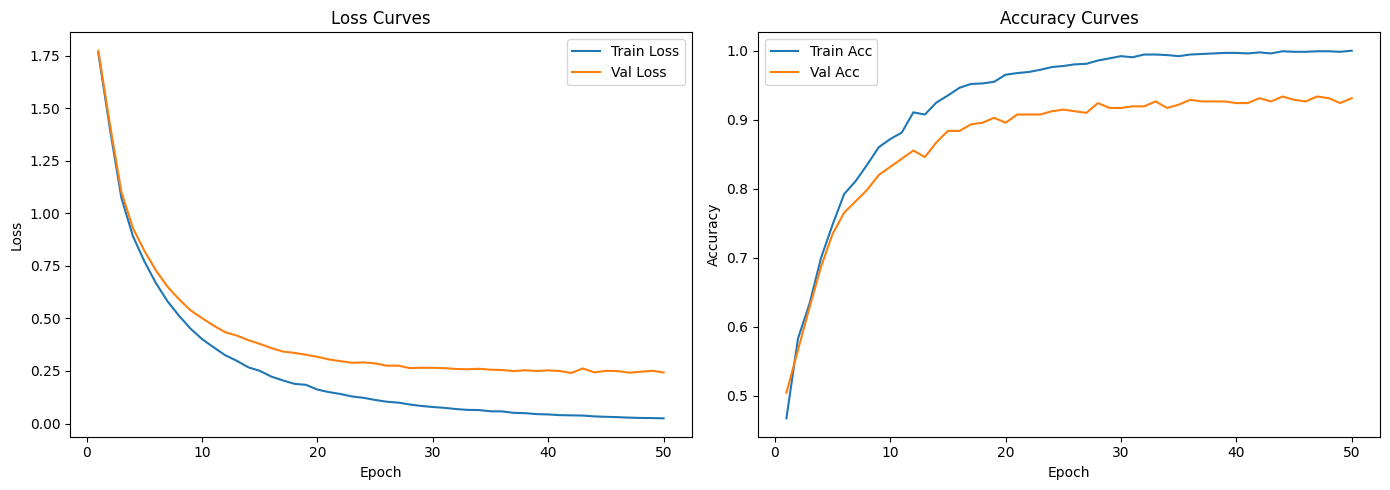

In [49]:
# Part 2.3 — The training loop
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(model, loader):
    total_loss  = 0.0
    correct     = 0
    total       = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds  = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    train_loss, train_acc = evaluate(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:3d} | train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

epochs = range(1, n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="Train Loss")
axes[0].plot(epochs, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train Acc")
axes[1].plot(epochs, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].legend()

plt.tight_layout()
plt.show()


Student Reasoning — Training 
1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule? 
2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 
3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?

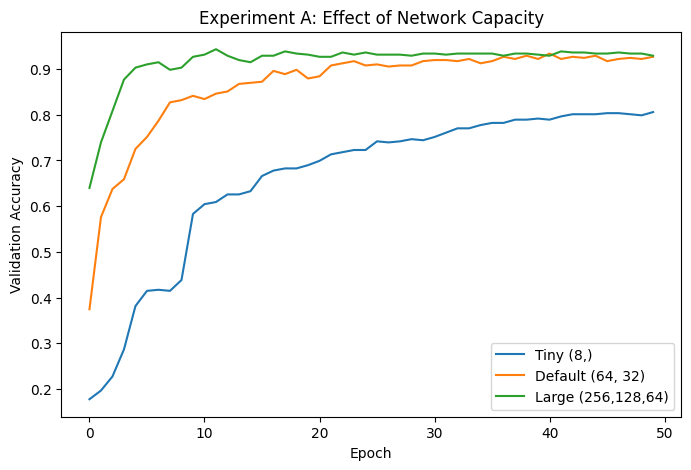

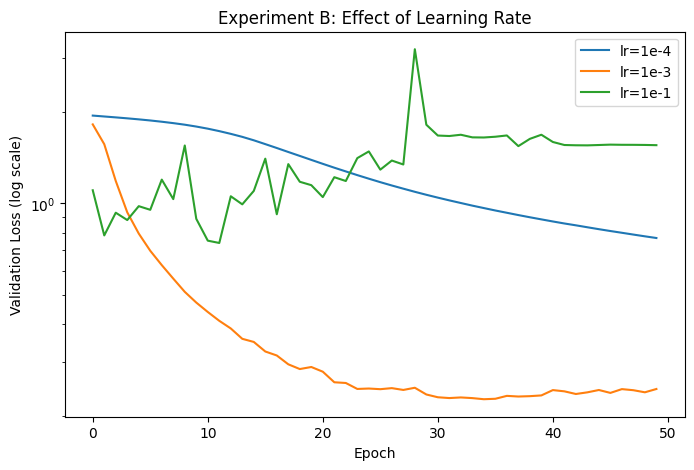

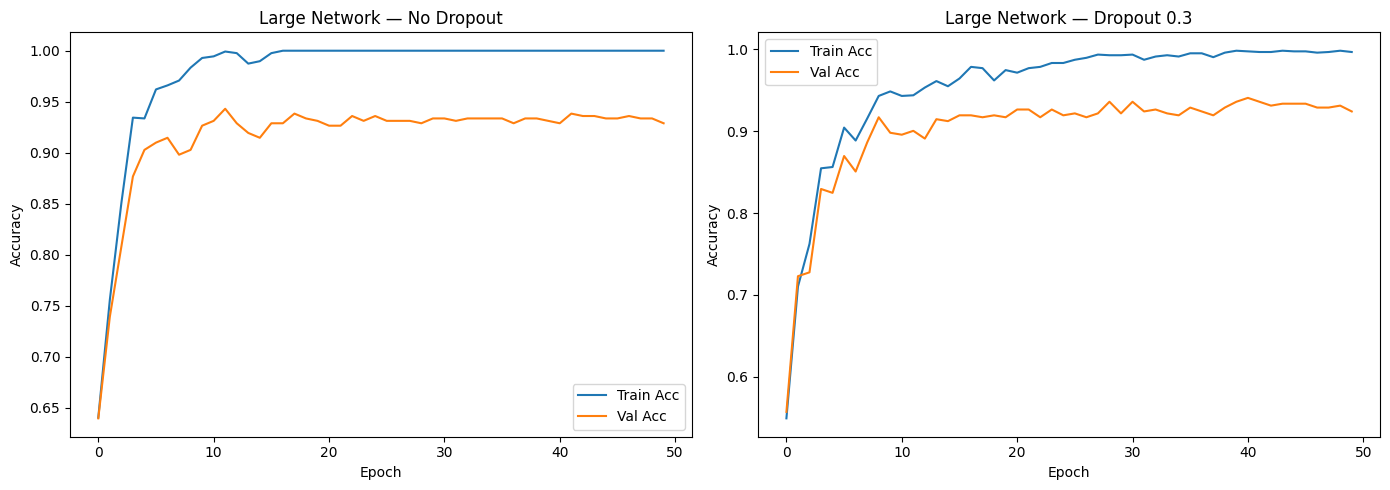

In [50]:
# Part 2.4 — Experiments: how training choices change the outcome

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    torch.manual_seed(RANDOM_STATE)

    train_loader_exp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_exp   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = FeedForwardNet(input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader_exp:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        train_loss, train_acc = evaluate(model, train_loader_exp)
        val_loss, val_acc = evaluate(model, val_loader_exp)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).

history_tiny  = run_experiment(hidden_sizes=(8,))
history_default = run_experiment(hidden_sizes=(64, 32))
history_large   = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(8, 5))
plt.plot(history_tiny["val_acc"], label="Tiny (8,)")
plt.plot(history_default["val_acc"], label="Default (64, 32)")
plt.plot(history_large["val_acc"], label="Large (256,128,64)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Effect of Network Capacity")
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).

history_lr_low  = run_experiment(lr=1e-4)
history_lr_mid  = run_experiment(lr=1e-3)
history_lr_high = run_experiment(lr=1e-1)

plt.figure(figsize=(8, 5))
plt.plot(history_lr_low["val_loss"], label="lr=1e-4")
plt.plot(history_lr_mid["val_loss"], label="lr=1e-3")
plt.plot(history_lr_high["val_loss"], label="lr=1e-1")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss (log scale)")
plt.title("Experiment B: Effect of Learning Rate")
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it

history_no_dropout   = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
history_with_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_no_dropout["train_acc"], label="Train Acc")
axes[0].plot(history_no_dropout["val_acc"], label="Val Acc")
axes[0].set_title("Large Network — No Dropout")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_with_dropout["train_acc"], label="Train Acc")
axes[1].plot(history_with_dropout["val_acc"], label="Val Acc")
axes[1].set_title("Large Network — Dropout 0.3")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Student Reasoning — Experiments 
1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting? 
2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3? 
3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.

Test Accuracy: 0.9385
Test Macro-F1: 0.9372

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        54
      Normal_Weight       0.88      0.90      0.89        58
     Obesity_Type_I       0.95      0.99      0.97        70
    Obesity_Type_II       0.97      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.83      0.86      0.85        58
Overweight_Level_II       0.96      0.88      0.92        58

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



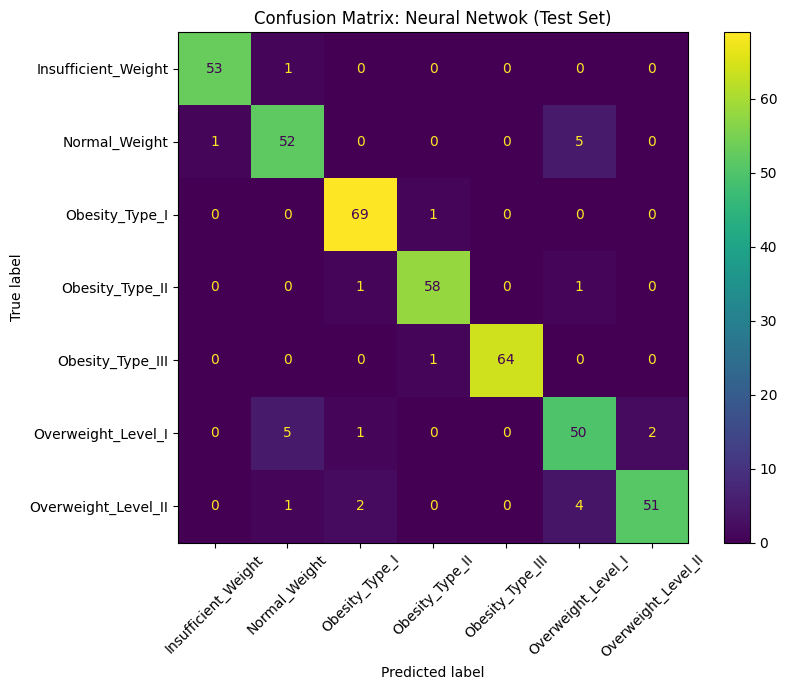


Comparison table:
                    Model  Test Accuracy  Test Macro-F1  Params/Trees
0   Random Forest (Lab 2)       0.995300       0.995500           100
1  Neural Network (Lab 3)       0.938534       0.937242          3591


In [51]:
# Part 2.5 — Final evaluation and showdown with Lab 2
# TODO: Load your best configuration's weights; model.eval().
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import time

best_model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()

all_preds  = []
all_labels = []
with torch.no_grad():
    for xb, yb, in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=le.classes_, ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Neural Netwok (Test Set)")
plt.tight_layout()
plt.show()

nn_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

comparison = pd.DataFrame({
    "Model": ["Random Forest (Lab 2)", "Neural Network (Lab 3)"],
    "Test Accuracy": [0.9953, test_acc],       
    "Test Macro-F1": [0.9955, test_f1],       
    "Params/Trees": [100, nn_params],          
})

print("\nComparison table:")
print(comparison)
     